Notebook for testing uncertainty propagation in CNN_DET.

In [3]:
%cd ..

/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo


In [4]:
from gerumo import *
from tensorflow.keras.models import load_model
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal
import pandas as pd
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/usr/lib/cuda'

/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/raw/MST_NectarCam.npy not found.
File ML1/raw/MST_NectarCam not found
/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/simple/MST_NectarCam.npy not found.
File ML1/simple/MST_NectarCam not found
/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/simple_shift/MST_NectarCam.npy not found.
File ML1/simple_shift/MST_NectarCam not found
/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/time/MST_NectarCam.npy not found.
File ML1/time/MST_NectarCam not found
/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/time_shift/MST_NectarCam.npy not found.
File ML1/time_shift/MST_NectarCam not found
/home

2026-09-29 02:31:22.640400: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-29 02:31:22.666857: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-29 02:31:22.666886: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-29 02:31:22.667566: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-29 02:31:22.671911: I tensorflow/core/platform/cpu_feature_guar

In [3]:
telescope_test_files = "./dataset/gamma-diffuse only/test_telescopes.csv"
events_test_files = "./dataset/gamma-diffuse only/test_events.csv"
target_domains = {
    "alt": [1.15, 1.3], 
    "az": [-0.25, 0.25], 
    "log10_mc_energy": [-2.351, 2.47]
}
min_number_of_observations = 4
assembler_config_file = "./train/output/Training gamma-diffuse/CNN-DET/log10_energy/cnn_assembler_full_diffusion_test.json"
version = "DL1"

In [4]:
dataset = load_dataset(events_test_files,telescope_test_files)
dataset = aggregate_dataset(dataset, az=True, log10_mc_energy=True)
dataset = filter_dataset(dataset,"DL1", telescopes=["LST_LSTCam","MST_NectarCam"],domain=target_domains)
dataset = dataset.groupby("event_unique_id").filter(lambda x: len(x) >= min_number_of_observations)
describe_dataset(dataset)

files 8
events 58835
observations 364173
obsevation by telescopes
type
MST    223379
LST    140794
Name: count, dtype: int64


In [5]:
dataset_by_observations = [None]*10
for i in range(10):
    dataset_by_observations[i] = dataset.groupby("event_unique_id").filter(lambda x: len(x) == min_number_of_observations + i)
    if(len(dataset_by_observations[i]) == 0):
        break
    print("Number of events with ", i+min_number_of_observations, " observations:")
    describe_dataset(dataset_by_observations[i])

Number of events with  4  observations:
files 8
events 18333
observations 73332
obsevation by telescopes
type
MST    45244
LST    28088
Name: count, dtype: int64
Number of events with  5  observations:
files 8
events 11557
observations 57785
obsevation by telescopes
type
MST    35497
LST    22288
Name: count, dtype: int64
Number of events with  6  observations:
files 8
events 8138
observations 48828
obsevation by telescopes
type
MST    29049
LST    19779
Name: count, dtype: int64
Number of events with  7  observations:
files 8
events 6396
observations 44772
obsevation by telescopes
type
MST    25256
LST    19516
Name: count, dtype: int64
Number of events with  8  observations:
files 8
events 4814
observations 38512
obsevation by telescopes
type
MST    22273
LST    16239
Name: count, dtype: int64
Number of events with  9  observations:
files 8
events 3309
observations 29781
obsevation by telescopes
type
MST    18148
LST    11633
Name: count, dtype: int64
Number of events with  10  obser

In [6]:
config, assembler = load_assembler_from_configuration(assembler_config_file)
telescopes = config["telescopes"]
input_image_mode = config["input_image_mode"]
input_image_mask = config["input_image_mask"]
input_features = config["input_features"]
targets = config["targets"]
target_mode = config["target_mode"]
target_mode_config = get_target_mode_config(config, target_mode)

preprocessing_parameters = config.get("preprocessing", {})
preprocess_input_pipes = {}
if ("MultiCameraPipe" in preprocessing_parameters):
    multicamera_parameters = preprocessing_parameters["MultiCameraPipe"]
    multicamera_pipe = MultiCameraPipe(version=version, **multicamera_parameters)
    preprocess_input_pipes['MultiCameraPipe'] = multicamera_pipe
if "TelescopeFeaturesPipe" in preprocessing_parameters:
    telescopefeatures_parameters = preprocessing_parameters["TelescopeFeaturesPipe"]
    telescope_features_pipe = TelescopeFeaturesPipe(version=version, **telescopefeatures_parameters)
    preprocess_input_pipes['TelescopeFeaturesPipe'] = telescope_features_pipe

preprocess_output_pipes = {}

#Select a random event from the dataset of 13 activated telescopes
selected_event_data = dataset_by_observations[9]
random_event_id = selected_event_data["event_unique_id"].sample().values[0]
selected_event_data_1 = selected_event_data[selected_event_data["event_unique_id"] == random_event_id]
random_event_id = selected_event_data["event_unique_id"].sample().values[0]
selected_event_data_2 = selected_event_data[selected_event_data["event_unique_id"] == random_event_id]
selected_event_data = pd.concat([selected_event_data_1, selected_event_data_2], ignore_index=True)

generator =  AssemblerGenerator(
                            selected_event_data, telescopes.keys(), len(selected_event_data), 
                            input_image_mode=input_image_mode,
                            input_image_mask=input_image_mask, 
                            input_features=input_features,
                            targets=targets,
                            target_mode=target_mode, 
                            target_mode_config=target_mode_config,
                            preprocess_input_pipes=preprocess_input_pipes,
                            preprocess_output_pipes=preprocess_output_pipes,
                            include_event_id=True,
                            include_true_energy=True,
                            version=version
                        )
generator_1 =  AssemblerGenerator(
                            selected_event_data_1, telescopes.keys(), len(selected_event_data_1), 
                            input_image_mode=input_image_mode,
                            input_image_mask=input_image_mask, 
                            input_features=input_features,
                            targets=targets,
                            target_mode=target_mode, 
                            target_mode_config=target_mode_config,
                            preprocess_input_pipes=preprocess_input_pipes,
                            preprocess_output_pipes=preprocess_output_pipes,
                            include_event_id=True,
                            include_true_energy=True,
                            version=version
                        )

2026-07-02 00:05:46.917671: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-02 00:05:46.942350: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-02 00:05:46.945604: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Cause: mangled names are not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: mangled names are not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [7]:
x, y ,meta = generator[0]
x_LST = x[0]["LST_LSTCam"]
x_MST = x[0]["MST_NectarCam"]
x_1, y_1 ,meta_1 = generator_1[0]
x_1_LST = x_1[0]["LST_LSTCam"]
x_1_MST = x_1[0]["MST_NectarCam"]

In [8]:
[prediccion_LST, prediccion_latente_LST, pesos_LST] = assembler.model_estimation(x_LST,"LST_LSTCam",verbose=0)
[prediccion_MST, prediccion_latente_MST, pesos_MST] = assembler.model_estimation(x_MST,"MST_NectarCam",verbose=0)

2026-07-02 00:05:49.099824: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906


In [9]:
prediccion_LST = assembler.model_estimation(x_LST,"LST_LSTCam",verbose=0)
prediccion_MST = assembler.model_estimation(x_MST,"MST_NectarCam",verbose=0)

In [10]:
test_LST = np.dot(prediccion_latente_LST[:],pesos_LST[0])
test_MST = np.dot(prediccion_latente_MST[:],pesos_MST[0])

In [11]:
print(test_LST + pesos_LST[1])
print(prediccion_LST[0],"\n")
print(test_MST + pesos_MST[1])
print(prediccion_MST[0])

[[-0.02437919]
 [ 0.04916054]
 [ 1.2347881 ]
 [ 0.21322992]]
[[-0.02442396]
 [ 0.04918358]
 [ 1.2350434 ]
 [ 0.21310827]] 

[[-0.01835185]
 [ 0.15519804]
 [-0.01240498]
 [-0.02642462]
 [ 0.00869578]
 [-0.0519093 ]
 [-0.1098409 ]
 [ 0.0195542 ]
 [ 0.01175433]]
[[-0.01835188]
 [ 0.15519801]
 [-0.01240498]
 [-0.02642465]
 [ 0.00869581]
 [-0.05190927]
 [-0.1098409 ]
 [ 0.01955423]
 [ 0.01175433]]


In [12]:
intensidad_LST = np.sum(x_LST[0][:, 0, :, :, 0], axis=(1,2))
intensidad_MST = np.sum(x_MST[0][:, 0, :, :, 0], axis=(1,2))
intensidad_total = np.sum(intensidad_LST) + np.sum(intensidad_MST)

In [13]:
cov_LST = np.cov(prediccion_latente_LST,rowvar=False, aweights=intensidad_LST)
cov_MST = np.cov(prediccion_latente_MST,rowvar=False, aweights=intensidad_MST)

In [14]:
varianza_LST = np.matmul(pesos_LST[0].flatten(),cov_LST)
varianza_LST = np.matmul(varianza_LST,pesos_LST[0])[0]
varianza_MST = np.matmul(pesos_MST[0].flatten(),cov_MST)
varianza_MST = np.matmul(varianza_MST,pesos_MST[0])[0]
intensidad_total_LST = np.sum(intensidad_LST)
intensidad_total_MST = np.sum(intensidad_MST)
varianza_total = varianza_LST * intensidad_total_LST**2 + varianza_MST * intensidad_total_MST**2
varianza_total = varianza_total / intensidad_total**2

In [15]:
media = np.dot(intensidad_LST,test_LST + pesos_LST[1]) + np.dot(intensidad_MST, test_MST + pesos_MST[1])
media = media/intensidad_total

In [17]:
results, predictions = assembler.evaluate(generator, return_predictions=True)
print(results)
print(predictions)

100%|██████████| 1/1 [00:00<00:00,  1.71it/s]


         event_id  true_mc_energy number_of_observations  \
0   5143_534703_7        1.159001                 [13.0]   
1  6089_2499806_2        4.049246                 [13.0]   

   true_log10_mc_energy  pred_log10_mc_energy  \
0              0.064084              0.306947   
1              0.607374              0.868230   

   standard_deviation_log10_mc_energy  predictions  
0                            0.488341            0  
1                            0.289821            1  
[array([[0.30694733],
       [0.86823044]]), array([[0.4883407 ],
       [0.28982085]])]


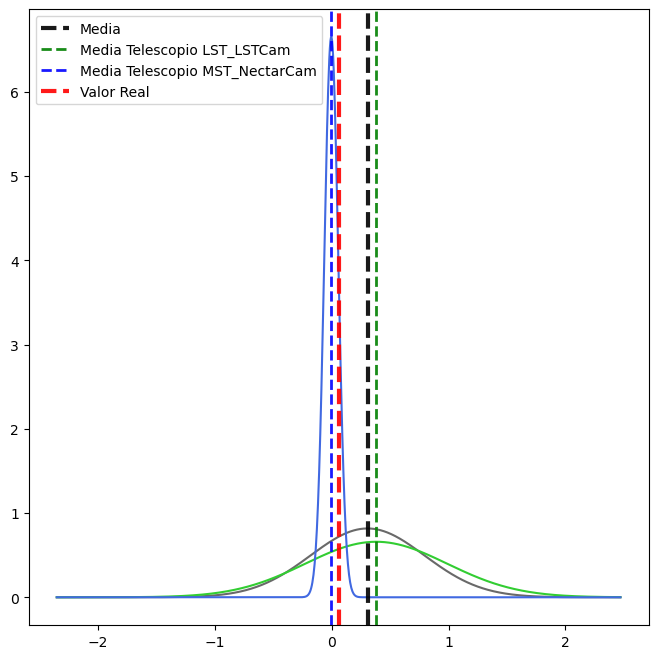

In [18]:
pred_plot_x = np.linspace(target_domains["log10_mc_energy"][0],target_domains["log10_mc_energy"][1],1000)
pred_plot_y = norm.pdf(pred_plot_x, loc = media, scale = np.sqrt(varianza_total))
pred_plot_y_LST = norm.pdf(pred_plot_x, loc = np.dot(intensidad_LST,test_LST + pesos_LST[1])/intensidad_total_LST, scale = np.sqrt(varianza_LST))
pred_plot_y_MST = norm.pdf(pred_plot_x, loc = np.dot(intensidad_MST,test_MST + pesos_MST[1])/intensidad_total_MST, scale = np.sqrt(varianza_MST))
plt.figure(figsize=(8,8))
plt.plot(pred_plot_x,pred_plot_y, color = "dimgray")
plt.plot(pred_plot_x,pred_plot_y_LST, color = "limegreen")
plt.plot(pred_plot_x,pred_plot_y_MST, color = "royalblue")
plt.axvline(x=media, c="black", linestyle="--", linewidth=3,
                 label="Media", alpha=0.9)
plt.axvline(x=np.dot(intensidad_LST,test_LST + pesos_LST[1])/intensidad_total_LST, c="green", linestyle="--", linewidth=2,
                 label="Media Telescopio LST_LSTCam", alpha=0.9)
plt.axvline(x=np.dot(intensidad_MST,test_MST + pesos_MST[1])/intensidad_total_MST, c="blue", linestyle="--", linewidth=2,
                 label="Media Telescopio MST_NectarCam", alpha=0.9)
plt.axvline(x=results["true_log10_mc_energy"].values[0], c="red", linestyle="--", linewidth=3,
                 label="Valor Real", alpha=0.9)
plt.legend()
plt.show()

In [9]:
result = assembler.predict(x)

2026-07-01 00:51:24.848136: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906


In [8]:
example = generator[0]

In [22]:
print(example)

([], array([], shape=(0, 1), dtype=float64), {'event_id': array([], dtype='<U14'), 'true_energy': array([], dtype=float64)})


In [17]:
layer_names = [layer.name for layer in LST_LSTCam_model.layers]
print(layer_names)
print(LST_LSTCam_model.layers[37].output_shape)

['image_input', 'encoder_hex_conv_layer', 'encoder_conv_layer_1_a', 'encoder_ReLU_1_a', 'encoder_batchnorm_1_a', 'encoder_conv_layer_1_b', 'encoder_ReLU_1_b', 'encoder_batchnorm_1_b', 'encoder_maxpool_layer_1', 'encoder_conv_layer_2_a', 'encoder_ReLU_2_a', 'encoder_batchnorm_2_a', 'encoder_conv_layer_2_b', 'encoder_ReLU_2_b', 'encoder_batchnorm_2_b', 'encoder_maxpool_layer_2', 'encoder_conv_layer_3_a', 'encoder_ReLU_3_a', 'encoder_batchnorm_3_a', 'encoder_conv_layer_3_b', 'encoder_ReLU_3_b', 'encoder_batchnorm_3_b', 'encoder_maxpool_layer_3', 'encoder_conv_layer_compress', 'encoder_conv_layer_to_latent', 'feature_input', 'encoder_flatten_to_latent', 'concatenate_1', 'logic_dense_0', 'logic_ReLU_0', 'logic_batchnorm_0', 'logic_dense_1', 'logic_ReLU_1', 'logic_batchnorm_1', 'logic_dense_2', 'logic_ReLU_2', 'logic_batchnorm_2', 'dense']
(None, 1)


In [ ]:
prediction_point = np.array([1.21, 0.008, 1.19, -0.02])
variance = np.array([[0.00000104, 0.00135414], [0, 0]])
covariance = np.array([0.00001, -0.000002])
intensity = np.array([50,150])
num_activated_telescopes = np.array([4, 1])
targets = np.array(["alt", "az"])
telescope_names = np.array(["LST_LSTCam", "MST_NectarCam"])
targets_values = np.array([1.2, 0])
target_domains_test = np.array([[1.15, 1.3], [-0.25, 0.25]])

In [30]:
def show_gaussian_prediction_2d_test(prediction, prediction_point, variance, covariance, intensity, targets, target_domains, telescope_names, targets_values=None, axis=None):
    if axis is None:
        fig = plt.figure(figsize=(8,8))
        axis = fig.add_subplot(projection='3d')
    if isinstance(target_domains, dict):
        target_domains = [[target_domains[t][0],target_domains[t][1]] for t in targets]
    x = np.linspace(target_domains[0][0],target_domains[0][1],1000)
    y = np.linspace(target_domains[1][0],target_domains[1][1],1000)
    x, y = np.meshgrid(x, y)

    total_intensity_mu = 0
    total_intensity_var = 0
    std_domain_1 = 0
    std_domain_2 = 0
    std_cov = 0
    mu_domain_1 = 0
    mu_domain_2 = 0
    #pred points: [LST_alt, LST_az, MST_alt, MST_az]
    #variance : [[LST_alt, LST_az],[MST_alt_MST_az]]
    #covariance: [LST, MST]
    #intensity : [LST, MST]
    #targets : ["alt", "az"]
    #telescope_names ["LST, MST"]
    #targets_values : [true_alt, true_az]
    for i in range(len(telescope_names)):
        if intensity[i] != 0:
            total_intensity_mu += intensity[i]
            mu_domain_1 += prediction_point[2*i]*intensity[i]
            mu_domain_2 += prediction_point[2*i + 1]*intensity[i]
            if variance[i][0] != 0:
                total_intensity_var += intensity[i]
                std_domain_1 += variance[i][0]*intensity[i]**2
                std_domain_2 += variance[i][1]*intensity[i]**2
                std_cov += covariance[i]*intensity[i]**2
    mu_domain_1 = mu_domain_1/total_intensity_mu
    mu_domain_2 = mu_domain_2/total_intensity_mu
    std_domain_1 = std_domain_1/(total_intensity_var**2)
    std_domain_2 = std_domain_2/(total_intensity_var**2)
    std_cov = std_cov/(total_intensity_var**2)


    data = multivariate_normal([mu_domain_1, mu_domain_2], [[std_domain_1, std_cov], [std_cov, std_domain_2]])
    prob_density = np.empty(x.shape + (2,))
    prob_density[:,:,0] = x
    prob_density[:,:,1] = y
    prob_density = data.pdf(prob_density)

    axis.plot_surface(x,y,prob_density, cmap= cm.viridis)
    axis.set_xlabel(targets[0])
    axis.set_ylabel(targets[1])
    return axis

In [31]:
ax = show_gaussian_prediction_2d_test(None,prediction_point,variance,covariance,intensity, num_activated_telescopes,targets,target_domains_test,telescope_names,targets_values)
plt.show()

UFuncTypeError: ufunc 'multiply' did not contain a loop with signature matching types (dtype('<U1'), dtype('float64')) -> None

In [46]:
def show_gaussian_prediction_2d_test_AI(
        prediction_point,
        variance,
        covariance,
        intensity,
        num_activated_telescopes,
        targets,
        target_domains,
        telescope_names,
        targets_values=None,
        axis=None):

    # ------------------------------------------------------------
    # Preparación del eje
    # ------------------------------------------------------------

    if axis is None:
        fig = plt.figure(figsize=(10, 9))
        axis = fig.add_subplot(projection='3d')

    if isinstance(target_domains, dict):
        target_domains = [
            [target_domains[t][0], target_domains[t][1]]
            for t in targets
        ]

    # Dominio de la gráfica
    x = np.linspace(
        target_domains[0][0],
        target_domains[0][1],
        300
    )

    y = np.linspace(
        target_domains[1][0],
        target_domains[1][1],
        300
    )

    x, y = np.meshgrid(x, y)

    # ------------------------------------------------------------
    # Convertir las entradas a numpy
    # ------------------------------------------------------------

    prediction_point = np.asarray(prediction_point, dtype=float)
    variance = np.asarray(variance, dtype=float)
    covariance = np.asarray(covariance, dtype=float)
    intensity = np.asarray(intensity, dtype=float)

    n_telescopes = len(telescope_names)

    # ------------------------------------------------------------
    # Variables para la predicción total
    # ------------------------------------------------------------

    valid_telescopes = []
    single_measure_telescopes = []

    #setting up the collor palette
    colors = cm.Set1(np.linspace(0,1,9))#9 colors to choose, 1 is reserved for results
    color_select = 2

    for i in range(n_telescopes):

        # Telescopio sin observación
        if intensity[i] <= 0:
            continue

        # Evitamos utilizar telescopios para los cuales
        # no se calculó la varianza.
        if variance[i][0] <= 0 or variance[i][1] <= 0:
            single_measure_telescopes.append(i)
            continue

        valid_telescopes.append(i)

    if len(valid_telescopes) == 0:
        if len(single_measure_telescopes) == 0:
            raise ValueError(
                "No hay telescopios con intensidad y varianza válidas."
            )
        z = np.full_like(x, 0)
        axis.plot_surface(
        x,
        y,
        z,
        cmap="viridis",
        alpha=0.65,
        linewidth=0,
        antialiased=True
    )
        telescope_handles = []
        for i in single_measure_telescopes:
            axis.scatter(
                prediction_point[2 * i],
                prediction_point[2 * i + 1],
                0,
                s=120,
                marker='o',
                c=colors[color_select],
            )
            telescope_handles.append(
                Line2D(
                    [0],
                    [0],
                    marker='o',
                    linestyle='',
                    markersize=8,
                    c=colors[color_select],
                    label=f"{telescope_names[i]} 1 activated"
                )
            )
            color_select += 1
        if targets_values is not None:
            axis.scatter(
                targets_values[0],
                targets_values[1],
                0,
                s=120,
                marker='X',
                c='r',
                label='Ground truth'
            )
        axis.set_xlabel(targets[0])
        axis.set_ylabel(targets[1])
        axis.set_zlabel("Probability density")
        
        handles, labels = axis.get_legend_handles_labels()
        
        axis.legend(
            handles + telescope_handles,
            labels + [h.get_label() for h in telescope_handles],
            loc='upper right'
        )
        return axis

    # ------------------------------------------------------------
    # Pesos normalizados por intensidad
    # ------------------------------------------------------------

    total_intensity = np.sum(
        intensity[valid_telescopes]
    )

    weights = {
        i: intensity[i] / total_intensity
        for i in valid_telescopes
    }

    # ------------------------------------------------------------
    # Media total
    #
    # mu = sum(alpha_i * mu_i)
    # ------------------------------------------------------------

    mu_total = np.zeros(2)

    for i in valid_telescopes:

        mu_i = np.array([
            prediction_point[2 * i],
            prediction_point[2 * i + 1]
        ])

        mu_total += weights[i] * mu_i

    # ------------------------------------------------------------
    # Covarianza total
    #
    # Sigma = sum(alpha_i^2 Sigma_i)
    #
    # suponiendo que las mediciones de telescopios
    # son independientes.
    # ------------------------------------------------------------

    covariance_total = np.zeros((2, 2))

    telescope_covariances = {}

    for i in valid_telescopes:

        sigma_i = np.array([
            [variance[i][0], covariance[i]],
            [covariance[i], variance[i][1]]
        ])

        telescope_covariances[i] = sigma_i

        covariance_total += (
            weights[i] ** 2
            * sigma_i
        )

    # ------------------------------------------------------------
    # Crear distribución total
    # ------------------------------------------------------------

    gaussian_total = multivariate_normal(
        mean=mu_total,
        cov=covariance_total,
        allow_singular=True
    )

    positions = np.empty(x.shape + (2,))
    positions[:, :, 0] = x
    positions[:, :, 1] = y

    probability_total = gaussian_total.pdf(positions)

    # ------------------------------------------------------------
    # Graficar distribución total
    # ------------------------------------------------------------

    surface = axis.plot_surface(
        x,
        y,
        probability_total,
        cmap="viridis",
        alpha=0.65,
        linewidth=0,
        antialiased=True
    )

    # ------------------------------------------------------------
    # Curvas de nivel de la distribución total
    # ------------------------------------------------------------

    # Se proyectan ligeramente por encima de z=0 para poder
    # observar claramente la extensión de la distribución.
    max_probability = np.max(probability_total)

    axis.contour(
        x,
        y,
        probability_total,
        levels=8,
        zdir='z',
        offset=0,
        cmap="viridis"
    )

    # ------------------------------------------------------------
    # Graficar cada telescopio
    # ------------------------------------------------------------

    telescope_handles = []
    prob_max = 0

    for i in valid_telescopes:

        mu_i = np.array([
            prediction_point[2 * i],
            prediction_point[2 * i + 1]
        ])

        sigma_i = telescope_covariances[i]

        gaussian_i = multivariate_normal(
            mean=mu_i,
            cov=sigma_i,
            allow_singular=True
        )

        probability_i = gaussian_i.pdf(positions)

        # Superficie individual.
        #
        # La hacemos bastante transparente para que la distribución
        # total siga siendo visible.
        axis.plot_surface(
            x,
            y,
            probability_i,
            cmap="plasma",
            alpha=0.20,
            linewidth=0,
            antialiased=True
        )

        # --------------------------------------------------------
        # Punto correspondiente a la predicción individual
        # --------------------------------------------------------

        z_i = gaussian_i.pdf(mu_i)

        prob_max = np.max(np.array([prob_max,z_i]))

        axis.scatter(
            mu_i[0],
            mu_i[1],
            z_i,
            s=70,
            marker='o',
            c=colors[color_select]
        )

        # --------------------------------------------------------
        # Contornos de la distribución individual
        # --------------------------------------------------------

        axis.contour(
            x,
            y,
            probability_i,
            levels=5,
            zdir='z',
            offset=0,
            cmap="plasma",
            alpha=0.7
        )

        telescope_handles.append(
            Line2D(
                [0],
                [0],
                marker='o',
                linestyle='',
                markersize=8,
                c=colors[color_select],
                label=f"{telescope_names[i]} {num_activated_telescopes[i]} activated"
            )
        )

        color_select += 1

    #telescopios de una medida
    
        for i in single_measure_telescopes:
            x_pred = prediction_point[2 * i]
            y_pred = prediction_point[2 * i + 1]
            #z_i = gaussian_total.pdf(np.array([x, y]))
            axis.scatter(
                x_pred,
                y_pred,
                prob_max,
                s=70,
                marker='o',
                c=colors[color_select]
            )
            axis.plot(
                [x_pred, x_pred],
                [y_pred, y_pred],
                [0, prob_max],
                linewidth = 3,
                c=colors[color_select]
            )
            telescope_handles.append(
                Line2D(
                    [0],
                    [0],
                    marker='o',
                    linestyle='',
                    markersize=8,
                    c=colors[color_select],
                    label=f"{telescope_names[i]} {num_activated_telescopes[i]} activated"
                )
            )
            color_select += 1
    
    # ------------------------------------------------------------
    # Predicción total
    # ------------------------------------------------------------

    z_total = gaussian_total.pdf(mu_total)

    axis.scatter(
        mu_total[0],
        mu_total[1],
        z_total,
        s=130,
        marker='*',
        c='b',
        label='Combined prediction'
    )

    

    # ------------------------------------------------------------
    # Ground truth
    # ------------------------------------------------------------

    if targets_values is not None:

        targets_values = np.asarray(
            targets_values,
            dtype=float
        )

        #z_truth = gaussian_total.pdf(targets_values)

        axis.scatter(
            targets_values[0],
            targets_values[1],
            prob_max,
            s=120,
            marker='X',
            c='r',
            label='Ground truth'
        )

        axis.plot(
            [targets_values[0], targets_values[0]],
            [targets_values[1], targets_values[1]],
            [0, prob_max],
            linewidth = 5,
            c='r'
        )

    # ------------------------------------------------------------
    # Etiquetas
    # ------------------------------------------------------------

    axis.set_xlabel(targets[0])
    axis.set_ylabel(targets[1])
    axis.set_zlabel("Probability density")

    # ------------------------------------------------------------
    # Leyenda
    # ------------------------------------------------------------

    handles, labels = axis.get_legend_handles_labels()

    axis.legend(
        handles + telescope_handles,
        labels + [h.get_label() for h in telescope_handles],
        loc='upper right'
    )

    # ------------------------------------------------------------
    # Imprimir información útil
    # ------------------------------------------------------------

    print("\nCombined prediction:")
    print(f"  {targets[0]} = {mu_total[0]}")
    print(f"  {targets[1]} = {mu_total[1]}")

    print("\nCombined covariance matrix:")
    print(covariance_total)

    print("\nCombined variances:")
    print(f"  Var({targets[0]}) = {covariance_total[0, 0]}")
    print(f"  Var({targets[1]}) = {covariance_total[1, 1]}")

    print("\nCombined standard deviations:")
    print(
        f"  sigma({targets[0]}) = "
        f"{np.sqrt(covariance_total[0, 0])}"
    )

    print(
        f"  sigma({targets[1]}) = "
        f"{np.sqrt(covariance_total[1, 1])}"
    )

    print(
        f"\nCovariance({targets[0]}, {targets[1]}) = "
        f"{covariance_total[0, 1]}"
    )

    return axis

/tmp/ipykernel_7252/3728041454.py:95: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axis.scatter(


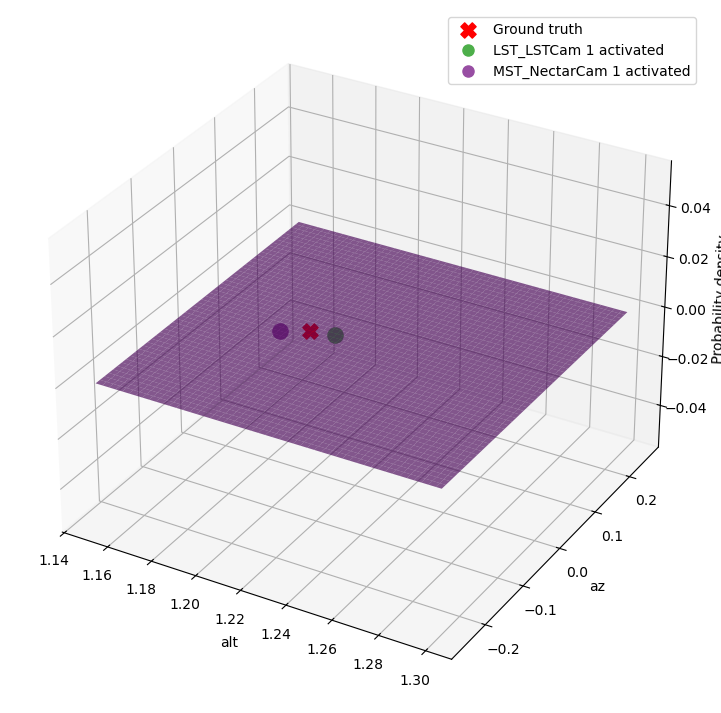

In [47]:
ax = show_gaussian_prediction_2d_test_AI(prediction_point,variance,covariance,intensity, num_activated_telescopes, targets,target_domains_test,telescope_names,targets_values)
plt.show()